# Unit Testing Loss Functions in the MAQT Architecture on the Toy Dataset: Iris
## 80 Training (Balanced) | Batch Size 8 | 30 Epochs | LR 0.05 | Seed 42 | Target (y) = 2 Classes | Data Reupload = 2

## Setup

PennyLane is now imported as `qp` instead of `qml`.

Source: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml

In [1]:
import matplotlib.pyplot as plt
import pennylane as qp
import torch
from pennylane import numpy as np
from torch import nn

from scripts.circuit import (
    build_forward_circuit,
    create_quantum_device,
    initialize_random_weights,
)
from scripts.constants import DEFAULT_NOISE_RATE
from scripts.loss import (
    compute_l_ce,
    compute_l_inter,
    compute_l_intra,
    maqt_loss,
)
from scripts.prototypes import EMAPrototypeBank, PrototypeBank
from scripts.quantum_metrics import fidelity
from scripts.utils import get_torch_device, to_torch_x

## Load Dataset: Iris

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
print(X.shape, y.shape)
y

(150, 4) (150,)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [4]:
# take only 2 classes
mask = np.isin(y, [0, 1])
X = X[mask]
y = y[mask]
print(X.shape, y.shape)
y

(100, 4) (100,)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

((80, 4), (20, 4), (80,), (20,))

## Data Preprocessing

Features are standardized with `StandardScaler()` so each one maps to rotation angles on a comparable scale, rather than larger-magnitude features dominating the encoded state.

In [7]:
X_test

array([[4.9, 2.4, 3.3, 1. ],
       [6.7, 3. , 5. , 1.7],
       [6.1, 2.9, 4.7, 1.4],
       [6.4, 3.2, 4.5, 1.5],
       [5. , 3.4, 1.5, 0.2],
       [5.8, 4. , 1.2, 0.2],
       [5.4, 3.4, 1.7, 0.2],
       [6.6, 3. , 4.4, 1.4],
       [5.7, 3.8, 1.7, 0.3],
       [4.6, 3.6, 1. , 0.2],
       [4.4, 3.2, 1.3, 0.2],
       [6.6, 2.9, 4.6, 1.3],
       [5. , 3.3, 1.4, 0.2],
       [4.4, 3. , 1.3, 0.2],
       [5.4, 3.7, 1.5, 0.2],
       [5. , 2.3, 3.3, 1. ],
       [5.6, 2.5, 3.9, 1.1],
       [5.2, 3.4, 1.4, 0.2],
       [6.3, 3.3, 4.7, 1.6],
       [5.4, 3. , 4.5, 1.5]])

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
# feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_test

array([[-0.90385683, -1.40880827,  0.30504541,  0.38346298],
       [ 2.01442531, -0.17029551,  1.49717691,  1.64663516],
       [ 1.0416646 , -0.3767143 ,  1.28680077,  1.10527565],
       [ 1.52804496,  0.24254208,  1.14655   ,  1.28572882],
       [-0.74173005,  0.65537967, -0.95721147, -1.06016236],
       [ 0.55528424,  1.89389244, -1.16758762, -1.06016236],
       [-0.0932229 ,  0.65537967, -0.8169607 , -1.06016236],
       [ 1.85229853, -0.17029551,  1.07642462,  1.10527565],
       [ 0.39315746,  1.48105485, -0.8169607 , -0.87970919],
       [-1.39023719,  1.06821726, -1.30783838, -1.06016236],
       [-1.71449076,  0.24254208, -1.09746223, -1.06016236],
       [ 1.85229853, -0.3767143 ,  1.21667538,  0.92482249],
       [-0.74173005,  0.44896088, -1.02733685, -1.06016236],
       [-1.71449076, -0.17029551, -1.09746223, -1.06016236],
       [-0.0932229 ,  1.27463606, -0.95721147, -1.06016236],
       [-0.74173005, -1.61522707,  0.30504541,  0.38346298],
       [ 0.23103067, -1.

## EDA

In [11]:
(y_train.shape, y_test.shape)

((80,), (20,))

In [12]:
classes, counts = np.unique(y_train, return_counts=True)
class_names = iris.target_names[classes]

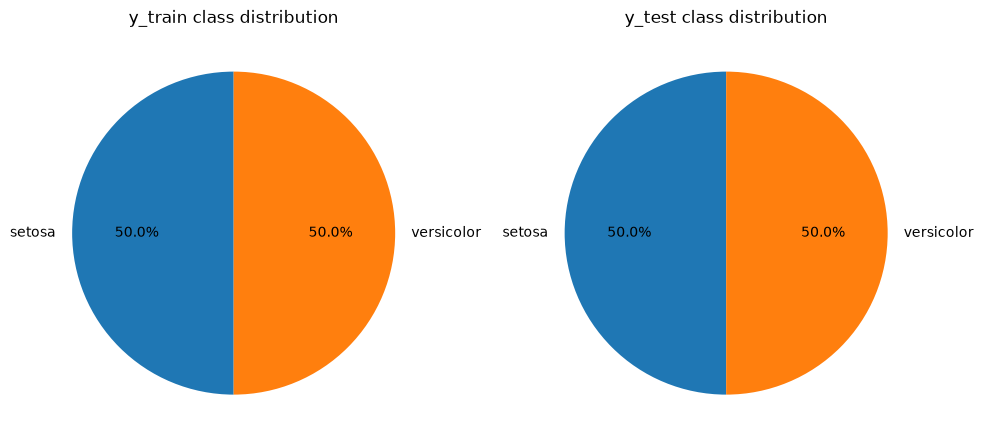

In [13]:
# pie chart
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# first pie chart
axes[0].pie(
    counts,
    labels=[class_names[c] for c in classes],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("y_train class distribution")

# second pie chart
axes[1].pie(
    counts,
    labels=[class_names[c] for c in classes],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("y_test class distribution")

plt.tight_layout()
plt.show()

## Angle Encoding, Data Reuploading, Circuit, and Weights

In [14]:
num_qubits = 4                  # 4 features = 4 qubits
num_classes = len(class_names)
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE
device = get_torch_device()

In [15]:
# initialize device
dev = create_quantum_device(num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

# initialize weights
theta = initialize_random_weights(num_layers, num_qubits, device)

# define classifier head
classifier_head = nn.Linear(num_qubits, num_classes).to(device)

# define loss function
ce_loss_fn = nn.CrossEntropyLoss()

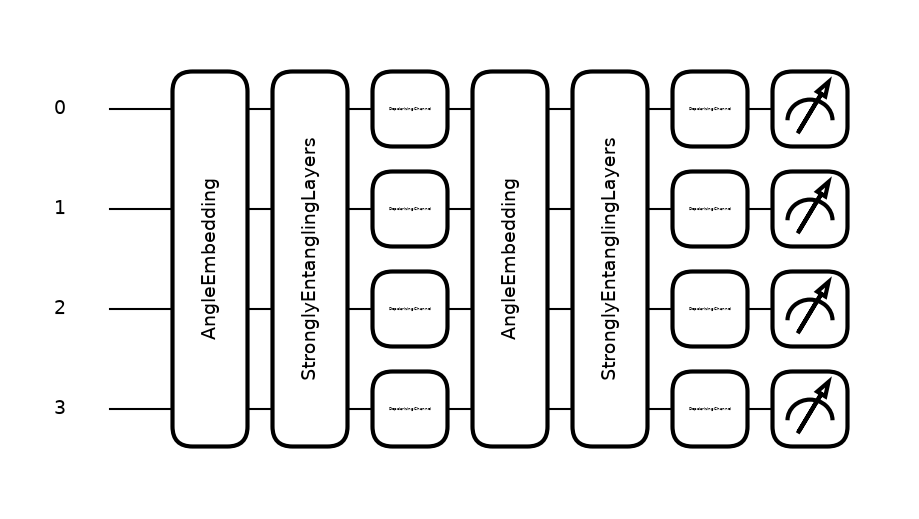

In [16]:
# check circuit
fig, ax = qp.draw_mpl(forward_circuit)(X_train, theta)
plt.show()

## Class Prototypes

In [17]:
bank = PrototypeBank(classes)
prototypes = bank.compute(theta, X_train, y_train, forward_circuit, device=device)

## Unit Test of Loss Functions

### Cross-Entropy Loss

$$
L_{CE}
$$

- **$L_{CE}$**: cross-entropy on $\rho(x)$

In [18]:
l_ce = compute_l_ce(theta, classifier_head, ce_loss_fn, X_train, y_train, forward_circuit, device)

# verify cross-entropy is finite and non-negative
assert torch.isfinite(l_ce) and l_ce.item() >= 0.0
print(f"[PASS] L_CE = {l_ce.item():.6f}")

[PASS] L_CE = 0.740936


### L Intra

$$
\lambda_1 L_{intra}
$$

- **$\lambda_1$**: Constant
- **$L_{intra}$**: average infidelity $(1 - fidelity)$ between each sample's state and its class prototype. It describes how far each $\rho(x)$ is from its own class prototype $\rho_c$.

In [19]:
l_intra = compute_l_intra(theta, X_train, y_train, prototypes, forward_circuit, device)

# verify L_intra is finite and mean prototype infidelity
assert torch.isfinite(l_intra) and 0.0 <= l_intra.item() <= 1.0 + 1e-5

# verify with manual computation
manual = []
with torch.no_grad():
    for c in [0, 1]:
        terms = []
        for x, y_i in zip(X_train, y_train):
            if int(y_i) != c:
                continue
            _, rho = forward_circuit(to_torch_x(x, device=device), theta)
            terms.append(1.0 - fidelity(rho, prototypes[c]))
        if terms:
            manual.append(torch.stack(terms).mean())
assert torch.allclose(l_intra, torch.stack(manual).mean(), atol=1e-5)
print(f"[PASS] L_intra = {l_intra.item():.6f}")

[PASS] L_intra = 0.201394


### L Inter

$$
\lambda_2 L_{inter}
$$

- **$\lambda_2$**: Constant
- **$L_{inter}$**: Negative mean trace distance from each sample state $\rho_\theta(x)$ to *other-class* prototypes (EMA / stop-grad targets).
  Repels samples from wrong-class centers so gradients flow through $\rho$ → $\theta$.
  Prototype-only pairwise TD is diagnostic only (`prototype_pair_separation`).


In [20]:
l_inter = compute_l_inter(theta, X_train, y_train, prototypes, forward_circuit, device)

# verify inter term is finite and in [-1, 0] (negative mean TD to other prototypes)
assert torch.isfinite(l_inter) and -1.0 - 1e-5 <= l_inter.item() <= 0.0

# lambda2 must affect theta grads (old proto-only inter had zero theta grad)
loss0, *_ = maqt_loss(
    theta, classifier_head, ce_loss_fn, X_train, y_train, prototypes, forward_circuit,
    lambda1=0.0, lambda2=0.0, device=device,
)
theta.grad = None
loss0.backward()
g0 = theta.grad.detach().clone()

loss1, *_ = maqt_loss(
    theta, classifier_head, ce_loss_fn, X_train, y_train, prototypes, forward_circuit,
    lambda1=0.0, lambda2=1.0, device=device,
)
theta.grad = None
loss1.backward()
g1 = theta.grad.detach().clone()
assert not torch.allclose(g0, g1, atol=1e-8), "lambda2 must change theta gradients"
print(
    f"[PASS] L_inter = {l_inter.item():.6f} | "
    f"lambda2 changes ||g|| {g0.norm().item():.4e} -> {g1.norm().item():.4e}"
)

[PASS] L_inter = -0.933642 | lambda2 changes ||g|| 7.5555e-02 -> 7.3782e-02


### MAQT Loss

$$
L = L_{CE} + \lambda_1 L_{intra} + \lambda_2 L_{inter}
$$

In [21]:
lambda1=0.5
lambda2=0.3

loss, l_ce2, l_intra2, l_inter2, *_ = maqt_loss(
    theta, classifier_head, ce_loss_fn, X_train, y_train, prototypes, forward_circuit,
    lambda1=lambda1, lambda2=lambda2, device=device,
)

# verify composition wiring is correct
assert torch.allclose(l_ce2, l_ce, atol=1e-5)
assert torch.allclose(l_intra2, l_intra, atol=1e-5)
assert torch.allclose(l_inter2, l_inter, atol=1e-5)
assert torch.allclose(loss, l_ce2 + lambda1 * l_intra2 + lambda2 * l_inter2, atol=1e-6)
print(f"[PASS] L = {loss.item():.6f}")

[PASS] L = 0.561540


## Loss Functions during Training

In [22]:
epochs = 30
batch_size = 8
lr = 0.05
optimizer = torch.optim.Adam(
    list([theta]) + list(classifier_head.parameters()), lr=lr
)

ema_protos = EMAPrototypeBank([0, 1])
history = {
    "loss": [],
    "l_ce": [],
    "l_intra": [],
    "l_inter": [],
}

for epoch in range(epochs):
    perm = np.random.permutation(len(X_train))
    epoch_loss, epoch_ce, epoch_intra, epoch_inter = [], [], [], []

    for start in range(0, len(perm), batch_size):
        idx = perm[start : start + batch_size]
        xb, yb = X_train[idx], y_train[idx]

        # stop-grad EMA targets from BEFORE this batch's update
        batch_prototypes = ema_protos.snapshot()

        loss, l_ce, l_intra, l_inter, y_used, rho_used = maqt_loss(
            theta, classifier_head, ce_loss_fn,
            xb, yb, batch_prototypes, forward_circuit,
            lambda1=lambda1, lambda2=lambda2, device=device,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update EMA AFTER the loss/step (matches train.py)
        ema_protos.update(ema_protos.batch_class_means(rho_used.detach(), y_used))

        epoch_loss.append(float(loss.item()))
        epoch_ce.append(float(l_ce.item()))
        epoch_intra.append(float(l_intra.item()))
        epoch_inter.append(float(l_inter.item()))

    history["loss"].append(float(np.mean(epoch_loss)))
    history["l_ce"].append(float(np.mean(epoch_ce)))
    history["l_intra"].append(float(np.mean(epoch_intra)))
    history["l_inter"].append(float(np.mean(epoch_inter)))
    print(
        f"epoch {epoch+1:02d}/{epochs} | "
        f"L={history['loss'][-1]:.4f} | "
        f"L_CE={history['l_ce'][-1]:.4f} | "
        f"L_intra={history['l_intra'][-1]:.4f} | "
        f"L_inter={history['l_inter'][-1]:.4f}"
    )

# final exact prototypes over all train points
prototypes = PrototypeBank([0, 1]).compute(
    theta, X_train, y_train, forward_circuit, device=device,
)

epoch 01/30 | L=0.5758 | L_CE=0.7306 | L_intra=0.1947 | L_inter=-0.8404
epoch 02/30 | L=0.4867 | L_CE=0.6597 | L_intra=0.2105 | L_inter=-0.9275
epoch 03/30 | L=0.3211 | L_CE=0.4907 | L_intra=0.2185 | L_inter=-0.9294
epoch 04/30 | L=0.1249 | L_CE=0.2953 | L_intra=0.2165 | L_inter=-0.9286
epoch 05/30 | L=0.0181 | L_CE=0.1826 | L_intra=0.2260 | L_inter=-0.9249
epoch 06/30 | L=-0.0551 | L_CE=0.1077 | L_intra=0.2243 | L_inter=-0.9167
epoch 07/30 | L=-0.0871 | L_CE=0.0823 | L_intra=0.2114 | L_inter=-0.9171
epoch 08/30 | L=-0.1067 | L_CE=0.0620 | L_intra=0.2128 | L_inter=-0.9167
epoch 09/30 | L=-0.1198 | L_CE=0.0509 | L_intra=0.2078 | L_inter=-0.9152
epoch 10/30 | L=-0.1296 | L_CE=0.0438 | L_intra=0.2029 | L_inter=-0.9161
epoch 11/30 | L=-0.1315 | L_CE=0.0394 | L_intra=0.2067 | L_inter=-0.9141
epoch 12/30 | L=-0.1334 | L_CE=0.0371 | L_intra=0.2067 | L_inter=-0.9129
epoch 13/30 | L=-0.1401 | L_CE=0.0308 | L_intra=0.2050 | L_inter=-0.9113
epoch 14/30 | L=-0.1425 | L_CE=0.0289 | L_intra=0.2035 |

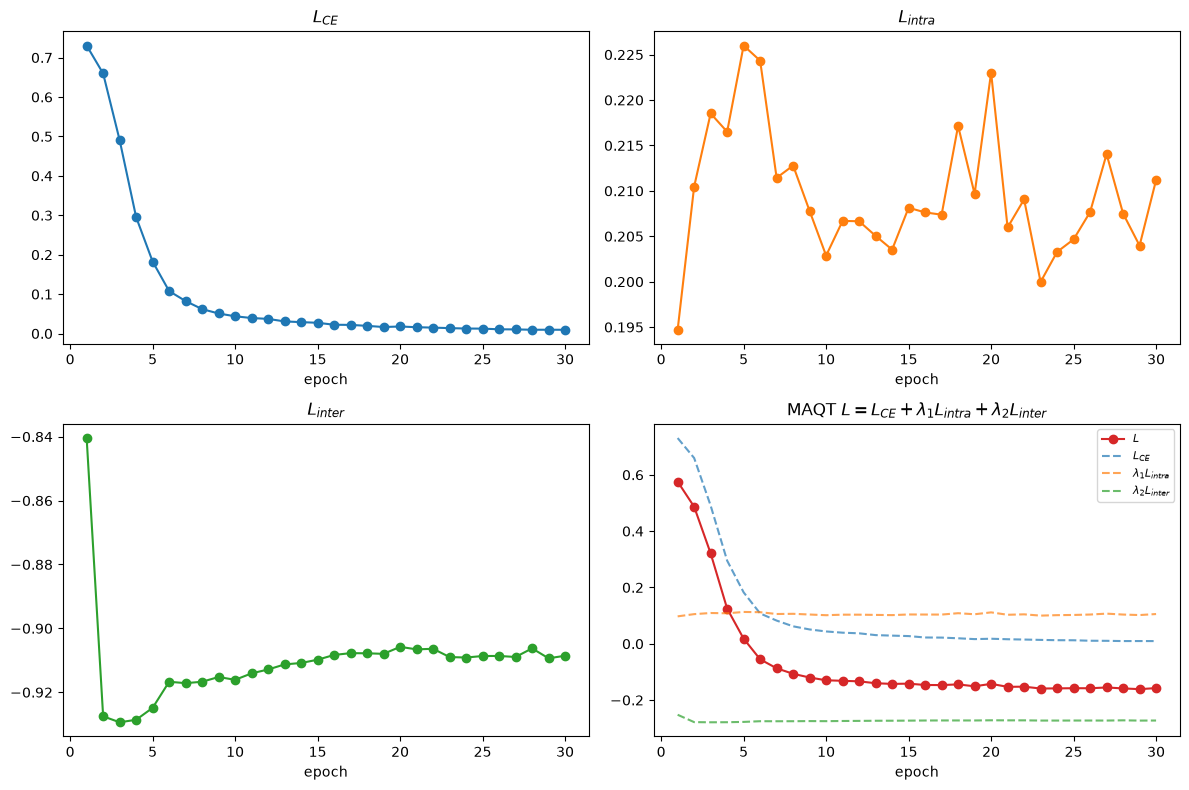

In [23]:
# plot each term + combined MAQT loss
epochs_axis = np.arange(1, len(history["loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(epochs_axis, history["l_ce"], marker="o")
axes[0, 0].set_title(r"$L_{CE}$")
axes[0, 0].set_xlabel("epoch")

axes[0, 1].plot(epochs_axis, history["l_intra"], marker="o", color="C1")
axes[0, 1].set_title(r"$L_{intra}$")
axes[0, 1].set_xlabel("epoch")

axes[1, 0].plot(epochs_axis, history["l_inter"], marker="o", color="C2")
axes[1, 0].set_title(r"$L_{inter}$")
axes[1, 0].set_xlabel("epoch")

axes[1, 1].plot(epochs_axis, history["loss"], marker="o", color="C3", label=r"$L$")
axes[1, 1].plot(epochs_axis, history["l_ce"], "--", alpha=0.7, label=r"$L_{CE}$")
axes[1, 1].plot(
    epochs_axis,
    [lambda1 * v for v in history["l_intra"]],
    "--", alpha=0.7, label=r"$\lambda_1 L_{intra}$",
)
axes[1, 1].plot(
    epochs_axis,
    [lambda2 * v for v in history["l_inter"]],
    "--", alpha=0.7, label=r"$\lambda_2 L_{inter}$",
)
axes[1, 1].set_title(r"MAQT $L = L_{CE}+\lambda_1 L_{intra}+\lambda_2 L_{inter}$")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()